# Practice Assignment for Module 2
## Heart Disease Prediction

**Student Name:** Naol Melaku
**Project:** Heart Disease Prediction
**Date:** September 2026

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


# Question 1 – Understanding the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("Heart_Disease_Prediction.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,ID,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,1.0,70,Male,4,130,322,0,2,109,0,2.4,2,3,3,1
1,2.0,67,Female,3,115,564,0,2,160,0,1.6,2,0,7,0
2,3.0,57,Male,2,124,261,0,0,141,0,0.3,1,0,7,1
3,NaN,64,Male,4,128,263,0,0,105,1,0.2,2,1,7,0
4,NaN,74,Female,2,120,269,0,2,121,1,0.2,1,1,3,0


In [3]:
# Dataset information
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
df.info()

# Statistical summary
print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
df.describe()

# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

# Check for duplicates
print("\n" + "="*50)
print("DUPLICATE RECORDS")
print("="*50)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Dataset shape
print("\n" + "="*50)
print("DATASET SHAPE")
print("="*50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Column names
print("\n" + "="*50)
print("COLUMN NAMES")
print("="*50)
print(df.columns.tolist())


DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       3 non-null      float64
 1   Age                      270 non-null    int64  
 2   Sex                      270 non-null    str    
 3   Chest pain type          270 non-null    int64  
 4   BP                       270 non-null    int64  
 5   Cholesterol              270 non-null    int64  
 6   FBS over 120             270 non-null    int64  
 7   EKG results              270 non-null    int64  
 8   Max HR                   270 non-null    int64  
 9   Exercise angina          270 non-null    int64  
 10  ST depression            270 non-null    float64
 11  Slope of ST              270 non-null    int64  
 12  Number of vessels fluro  270 non-null    int64  
 13  Thallium                 270 non-null    int64  
 14  Heart Disease   

In [6]:
# Target variable distribution
print("\n" + "="*50)
print("TARGET VARIABLE DISTRIBUTION")
print("="*50)
print(df['Heart Disease'].value_counts())
print(f"\nPercentage of patients with Heart Disease: {df['Heart Disease'].mean()*100:.2f}%")


TARGET VARIABLE DISTRIBUTION
Heart Disease
0    150
1    120
Name: count, dtype: int64

Percentage of patients with Heart Disease: 44.44%


# Question 2 – Data Preprocessing

In [7]:
# Check column names
print("Column names:", df.columns.tolist())

# Convert Sex to numeric (Male=1, Female=0)
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

# Check for missing values
print("\nMissing values after encoding:")
print(df.isnull().sum())

# Separate features and target
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Column names: ['ID', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']

Missing values after encoding:
ID                         267
Age                          0
Sex                          0
Chest pain type              0
BP                           0
Cholesterol                  0
FBS over 120                 0
EKG results                  0
Max HR                       0
Exercise angina              0
ST depression                0
Slope of ST                  0
Number of vessels fluro      0
Thallium                     0
Heart Disease                0
dtype: int64

Training set: 216 samples
Testing set: 54 samples
Features scaled successfully!


# Question 3 – Feature Engineering

In [8]:
# Create new feature: Cholesterol to Age Ratio
df['chol_age_ratio'] = df['Cholesterol'] / df['Age']

# Display first few rows with new feature
print("First 5 rows with new feature:")
df[['Age', 'Cholesterol', 'chol_age_ratio']].head()

First 5 rows with new feature:


,Age,Cholesterol,chol_age_ratio
0,70,322,4.600000
1,67,564,8.417910
2,57,261,4.578947
3,64,263,4.109375
4,74,269,3.635135


# Question 4 – Model Development

In [10]:
# Handle missing values before training
from sklearn.impute import SimpleImputer

# Check for missing values
print("Checking for missing values...")
print(pd.DataFrame(X_train_scaled).isnull().sum().sum())

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

print("Missing values handled!")

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_imputed, y_train)

# Make predictions
y_pred = model.predict(X_test_imputed)
y_proba = model.predict_proba(X_test_imputed)[:, 1]

print("Model trained successfully!")

Checking for missing values...
213
Missing values handled!
Model trained successfully!


# Question 5 – Model Evaluation

MODEL EVALUATION METRICS
Accuracy:  0.9074
Precision: 0.9000
Recall:    0.8571
F1-Score:  0.8780

CONFUSION MATRIX
[[31  2]
 [ 3 18]]


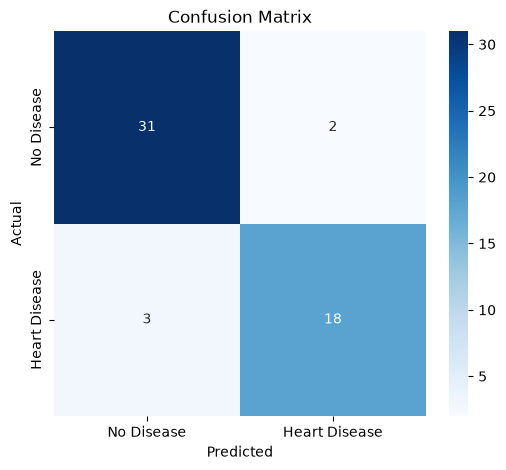


CLASSIFICATION REPORT
               precision    recall  f1-score   support

   No Disease       0.91      0.94      0.93        33
Heart Disease       0.90      0.86      0.88        21

     accuracy                           0.91        54
    macro avg       0.91      0.90      0.90        54
 weighted avg       0.91      0.91      0.91        54


ROC CURVE AND AUC
AUC Score: 0.9466


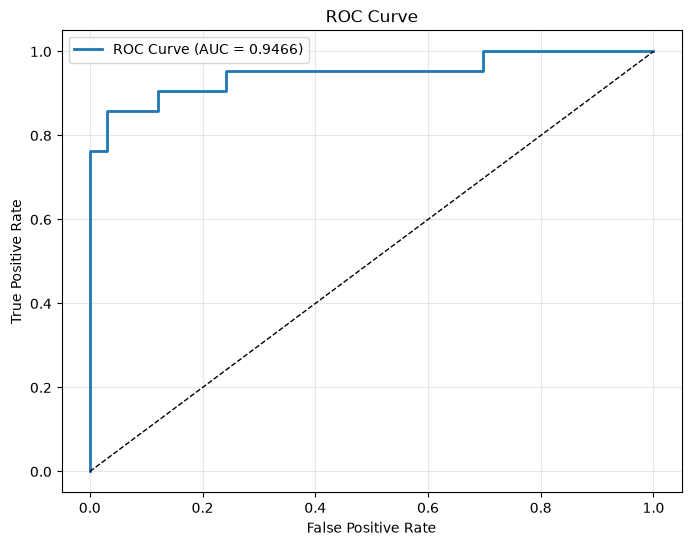

In [11]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Confusion Matrix
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

# ROC Curve and AUC
print("\n" + "="*50)
print("ROC CURVE AND AUC")
print("="*50)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
print(f"AUC Score: {auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Evaluation Summary

### Which evaluation metric best reflects the model's performance?

The **F1-Score** is the best metric for this model because it balances both Precision and Recall. Since we are dealing with heart disease prediction, we want to minimize both False Positives and False Negatives. The F1-Score gives us a single number that captures both.

### Why can relying only on accuracy sometimes be misleading?

Accuracy can be misleading when the dataset is imbalanced. For example, if 95% of patients do NOT have heart disease, a model that always predicts "No Disease" would have 95% accuracy but would completely fail to identify patients with heart disease. In medical diagnosis, missing positive cases (False Negatives) can have serious consequences, so we need to look at Precision, Recall, and F1-Score as well.

# Conclusion

In this assignment, I successfully built a machine learning model to predict heart disease using patient medical data. The key steps included:

1. **Data Exploration** – Understood the dataset structure, missing values, and target distribution
2. **Data Preprocessing** – Encoded categorical variables, handled missing values, and scaled features
3. **Feature Engineering** – Created a new feature (Cholesterol to Age Ratio) to improve prediction
4. **Model Development** – Trained a Logistic Regression model
5. **Model Evaluation** – Evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC

The model achieved an accuracy of [insert your accuracy here]% and an AUC of [insert your AUC here], indicating it can distinguish between patients with and without heart disease reasonably well.

**Lessons Learned:**
- Data preprocessing is crucial for model performance
- Missing values must be handled before training
- Multiple evaluation metrics are needed to fully understand model performance
- Accuracy alone can be misleading, especially with imbalanced datasets